In [1]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
from brainspace.gradient import GradientMaps
from my_utils import get_basic_mask
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd

bids_folder_matrices = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'
bids_folder = '/mnt_03/ds-dnumrisk'
plot_folder = op.join(bids_folder_matrices, 'plots_and_ims/gradient_stuff')
phenotype_folder = op.join(bids_folder_matrices, 'derivatives/phenotype')

# Create directories if they do not exist
os.makedirs(plot_folder, exist_ok=True)
os.makedirs(phenotype_folder, exist_ok=True)

from os import listdir
subList = [f[4:6] for f in listdir(op.join(bids_folder)) if f[0:4] == 'sub-' and len(f)==6]

fsaverage = fetch_surf_fsaverage('fsaverage5') 

# add group info
df_participants = pd.read_csv(op.join(bids_folder, 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')
group_list = group_list#.reset_index()

In [8]:
print(subList)

['21', '59', '54', '15', '52', '08', '57', '50', '36', '56', '02', '22', '01', '19', '23', '06', '18', '13', '03', '31', '55', '41', '65', '49', '29', '34', '17', '27', '30', '51', '20', '66', '24', '46', '39', '47', '14', '37', '04', '61', '45', '26', '58', '33', '40', '64', '32', '11', '35', '16', '38', '48', '63', '43', '10', '53', '05', '07', '09', '12', '62', '28', '42', '25', '44', '60']


In [2]:
# get masks
surf_mask_L = op.join(bids_folder, 'derivatives/surface_masks', 'desc-NPC_L_space-fsaverage5_hemi-lh.label.gii')
surf_mask_L = nib.load(surf_mask_L).agg_data()
surf_mask_R = op.join(bids_folder, 'derivatives/surface_masks', 'desc-NPC_R_space-fsaverage5_hemi-rh.label.gii')
surf_mask_R = nib.load(surf_mask_R).agg_data()
nprf_r2 = np.concatenate((surf_mask_L, surf_mask_R))

mask, labeling_noParcel = get_basic_mask()
#nprf_r2_mask = np.bool_(nprf_r2[mask])
nprf_r2 = np.bool_(nprf_r2)

np.shape(nprf_r2)

[get_dataset_dir] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


(20484,)

In [ ]:
## load in gradients

n_gradients = 5
stimuli = ['1', '2']  # List of stimuli kinds
df_gms = {}  # Dictionary to store DataFrames for each stimulus

for stim in stimuli:  # Loop through each stimulus
    gms_aligned = {f'g{i+1}': [] for i in range(n_gradients)}

    for sub in subList:
        try:
            source_folder_gm = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}')
            gm_aligned_path = op.join(source_folder_gm, f'sub-{sub}_g-aligned_space-fsaverag5_n10_stimulus_{stim}_betas.npy')
            
            # Attempt to load the file
            gm_aligned = np.load(gm_aligned_path)
            
            # Append gradient data
            for i in range(n_gradients):
                gms_aligned[f'g{i+1}'].append(gm_aligned[i, :])
        except FileNotFoundError:
            print(f"File not found for subject {sub}, stimulus {stim}. Adding NaN values...")
            # Append NaN values for missing data
            for i in range(n_gradients):
                gms_aligned[f'g{i+1}'].append(np.full((gm_aligned.shape[1],), np.nan))
        except Exception as e:
            print(f"An error occurred for subject {sub}, stimulus {stim}: {e}. Adding NaN values...")
            # Append NaN values for missing data
            for i in range(n_gradients):
                gms_aligned[f'g{i+1}'].append(np.full((gm_aligned.shape[1],), np.nan))
    
    df_gms[stim] = gms_aligned

sub_array = np.array([int(i) for i in subList])


File not found for subject 03, stimulus 1. Skipping...
File not found for subject 03, stimulus 2. Skipping...


In [5]:
print(stim)

2


In [45]:
df_gms['stimulus_2']
#print(df_gms[stim].columns)

{'g1': [array([ 3.10862475, -0.32877406,  5.72849156, ..., -0.21611274,
          0.10357919, -2.27256372]),
  array([ 3.38128785,  2.27440586,  4.28381335, ..., -1.7418219 ,
         -2.29952045, -5.02372903]),
  array([ 4.69229286,  3.23654589,  5.36582555, ..., -4.47351184,
         -4.9147626 , -4.15564964]),
  array([ 6.83313807,  0.87117356,  5.8512886 , ..., -1.44719817,
         -2.08691731, -2.23645199]),
  array([ 1.77687739, -1.42771943,  2.93040953, ..., -2.09034423,
         -2.20954579, -2.69876674]),
  array([ 2.48423681,  0.32709785,  4.43794918, ..., -2.84853912,
         -3.84979681, -3.57794583]),
  array([-0.02651333,  3.19564175,  1.94650033, ..., -2.17257191,
         -2.89123472, -2.55026107]),
  array([ 4.2407967 ,  0.28326282,  6.76114936, ..., -0.76922795,
          0.55876481,  1.04227448]),
  array([ 5.1144163 ,  3.17218912,  3.94833122, ..., -1.52600638,
         -1.56664721, -1.55206769]),
  array([ 5.56257668,  2.24419277,  5.29797549, ..., -2.13107674,
 

In [6]:
stimuli = '1' #[stimulus_1, 'stimulus_2', 'remaining']  # List of stimuli kinds
gms_stim = df_gms[stimuli]


In [39]:
print(stim)

remaining


In [7]:
# take NPC as a network and compute 1D dispersion for all stimuli
n_grad = 2
dispersion_results = {}  # Dictionary to store results for each stimulus

g = np.array(gms_stim[f'g{n_grad}']).T # n_vertices x n_subjects
print(stim)
# Get the gradient loadings of the nodes of the ROI, for each subject
G_net = g[nprf_r2]

# Compute centroid and dispersion
centroid_cog_net = np.nanmedian(G_net, axis=0)
dist_nodes_to_centroid = G_net - centroid_cog_net  # shape: number of nodes in network x N
NPC_dispersion = np.nanmean((dist_nodes_to_centroid**2), axis=0)

# Create a DataFrame for this stimulus
df = pd.DataFrame(np.array([NPC_dispersion, centroid_cog_net]).T, index=sub_array, columns=['NPC_dispersion', 'NPC_centroid'])
df.index.name = 'subject'
df = df.join(group_list).set_index('group', append=True)

# Store the DataFrame in the results dictionary
dispersion_results[stim] = df
# df.to_csv(op.join(phenotype_folder, f'withinNdispersion-NPC_grad-{n_grad}.csv'))
df.head()

2


ValueError: Shape of passed values is (65, 2), indices imply (66, 2)

In [41]:
print(stim)

remaining


In [42]:
# 2D dispersion measure for all stimuli
n_grad = 'both 2D'


g1 = np.array(gms_stim[f'g1']).T
g2 = np.array(gms_stim[f'g2']).T

# Get the gradient loadings of the nodes of the ROI, for each subject
G1_net = g1[nprf_r2]
G2_net = g2[nprf_r2]
G_net = np.stack([G1_net, G2_net], axis=-1)  # shape: number of nodes in network x N x 2
centroid_cog_net = np.nanmedian(G_net, axis=0)  # shape: N x 2

# Compute the 2D Euclidean distance between each node and the centroid for each subject
dist_nodes_to_centroid = G_net - centroid_cog_net  # shape: number of nodes in network x N x 2
squared_distances = np.sum(dist_nodes_to_centroid**2, axis=-1)  # sum squares across 2D (last axis), shape: number of nodes in network x N

# Compute the within-network dispersion as the mean squared distance
NPC_2d_dispersion = np.nanmean(squared_distances, axis=0)  # shape: N

df = pd.DataFrame(NPC_2d_dispersion.T, index=sub_array, columns=['NPC_2D_dispersion'])
df.index.name = 'subject'
df = df.join(group_list).set_index('group', append=True)

# df.to_csv(op.join(phenotype_folder, f'withinNdispersion-NPC_grad-{n_grad}.csv'))

In [43]:
print(stim)

remaining


Stimulus: remaining, Stats: TtestResult(statistic=-2.871937046936626, pvalue=0.005686303106634974, df=58.078511432919896)


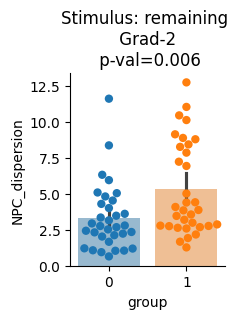

In [46]:
from scipy.stats import ttest_ind

y_var = 'NPC_2D_dispersion' if n_grad == 'both 2D' else 'NPC_dispersion'  # Variable to analyze

tmp = df.copy()

# Create the plot
figure, axes = plt.subplots(1, 1, figsize=(2, 2.5))
sns.barplot(data=tmp.reset_index(), x='group', hue='group', y=y_var, alpha=0.5, legend=False)
sns.swarmplot(data=tmp.reset_index(), x='group', hue='group', y=y_var, size=6, legend=False)

# Perform t-test
stats = ttest_ind(tmp.xs(0, 0, 'group')[y_var], tmp.xs(1, 0, 'group')[y_var], axis=0, equal_var=False)
p_val = np.round(stats.pvalue, 3)
print(f"Stimulus: {stim}, Stats: {stats}")

# Set plot title and labels
axes.set(title=f'Stimulus: {stim} \n Grad-{n_grad} \n p-val={p_val}', ylabel=y_var, xlabel='group')
sns.despine()